In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\Anton Wijaya\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "../../../data/eval_results_gpt5_mini.csv",
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [4]:
question_emb = model.encode(df["question"].tolist())
answer_emb = model.encode(df["answer"].tolist())

In [5]:
similarities = [
    cosine_similarity([q], [a])[0][0]
    for q, a in zip(question_emb, answer_emb)
]

In [6]:
df["similarity_score"] = similarities
df[["question", "answer", "similarity_score"]].head(100)

,question,answer,similarity_score
0,Laptop apa yang cocok untuk gaming budget 15 j...,Berikut ringkasan spesifik dari katalog (berda...,0.712955
1,"Laptop ringan untuk kuliah, RAM minimal 8GB",Berikut pilihan dari daftar yang memenuhi syar...,0.629432
2,"Saya punya budget 8 juta, laptop apa yang pali...",Rekomendasi saya: Lenovo ThinkPad L15 (judul: ...,0.513618
3,Lebih baik pilih laptop dengan SSD 512GB atau ...,Singkat: Kalau sering meng-install banyak apli...,0.673881
4,Laptop apa yang cocok untuk kerja kantoran ful...,Rekomendasi sesuai budget maksimal Rp7.000.000...,0.598379
...,...,...,...
95,"Kalau saya punya budget 10 juta, sebaiknya pil...","maaf, datanya belum cukup",0.447801
96,Laptop apa yang cocok untuk mahasiswa teknik s...,Rekomendasi berdasarkan data produk yang terse...,0.607623
97,Saya ingin laptop yang enak dipakai untuk kons...,Berikut rekomendasi laptop dalam batas budget ...,0.603919
98,Laptop apa yang cocok untuk developer fullstac...,Rekomendasi berdasarkan data produk yang ada:\...,0.629516


In [7]:
GROUND_TRUTH_THRESHOLD = 0.7
PREDICTION_THRESHOLD = 0.6

df["is_relevant"] = (df["similarity_score"] >= GROUND_TRUTH_THRESHOLD).astype(int)
df["predicted_relevant"] = (df["similarity_score"] >= PREDICTION_THRESHOLD).astype(int)

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(df["is_relevant"], df["predicted_relevant"])
print(cm)

print(classification_report(df["is_relevant"], df["predicted_relevant"]))

[[26 51]
 [ 0 23]]
              precision    recall  f1-score   support

           0       1.00      0.34      0.50        77
           1       0.31      1.00      0.47        23

    accuracy                           0.49       100
   macro avg       0.66      0.67      0.49       100
weighted avg       0.84      0.49      0.50       100



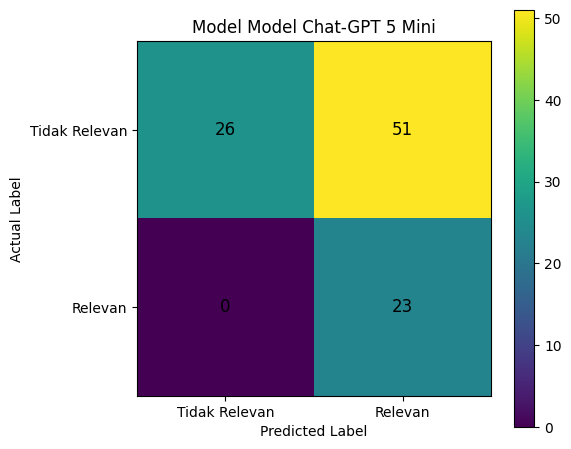

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Model Model Chat-GPT 5 Mini")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks([0,1], ["Tidak Relevan", "Relevan"])
plt.yticks([0,1], ["Tidak Relevan", "Relevan"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()